Accuracy: 0.8

Confusion Matrix:
[[3 0]
 [1 1]]

Feature Importance:
     Feature  Importance
4     Snacks    0.353527
3  Breakfast    0.263242
1  Newspaper    0.146475
0       Milk    0.133831
2       Eggs    0.102925


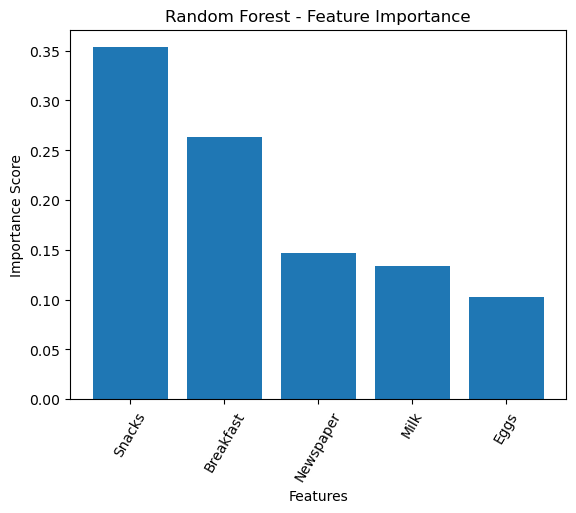

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
dataset = pd.read_csv("Knn_Customers.csv")
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
 n_estimators=100, # number of trees
 random_state=0
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
feature_importance = rf.feature_importances_
feature_names = dataset.columns[:-1]
importance_df = pd.DataFrame({
 "Feature": feature_names,
 "Importance": feature_importance
})
importance_df = importance_df.sort_values(by="Importance", ascending=False)
print("\nFeature Importance:")
print(importance_df)
plt.figure()
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Random Forest - Feature Importance")
plt.xticks(rotation=60)
plt.show()